In [1]:
!pip install pandas matplotlib seaborn openpyxl
import numpy as np

In [2]:
#IBP Product Review Analysis - Go/No-Go + KPIs
#Dataset: 100 SKUs
#Output: Excel con análisis + gráficos + recomendaciones


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Configuración
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
output_file = "IBP_Product_Review_Analysis.xlsx"

In [15]:
#Carga de datos
print("Cargando dataset...")
df = pd.read_csv("ibp_product_review_dataset_100.csv", parse_dates=['Fecha_Lanzamiento', 'Fecha_Fin_Proyectada'])
df

Cargando dataset...


C:\Users\marib\AppData\Local\Temp\ipykernel_22628\4227073760.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv("ibp_product_review_dataset_100.csv", parse_dates=['Fecha_Lanzamiento', 'Fecha_Fin_Proyectada'])
C:\Users\marib\AppData\Local\Temp\ipykernel_22628\4227073760.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv("ibp_product_review_dataset_100.csv", parse_dates=['Fecha_Lanzamiento', 'Fecha_Fin_Proyectada'])


,SKU,ID_Producto,Nombre_Producto,Categoria,Familia,Etapa_Ciclo_Vida,Fecha_Lanzamiento,Fecha_Fin_Proyectada,Ventas_Ultimos_12M_USD,Ventas_Pronosticadas_12M_USD,Variacion_YoY_Pct,Margen_Bruto_Pct,Inventario_Actual_Unid,Rotacion_Inventario,Volumen_Clientes_Unicos,Cuota_Mercado_Pct,Proyectos_NPI,Riesgos_Alertas,Estrategia_Recomendada
0,SKU001,PRD001,SmartHub Pro,Electrónicos,Hubs,Madurez,2022-03-15,2026-12-31,285000,270000,-5.3,42,8500,3.8,4200,18.5,Lanzado Q1,Declive leve (-5%),Mantener
1,SKU002,PRD002,UltraCharge 65W,Electrónicos,Cargadores,Crecimiento,2023-06-20,2028-06-30,420000,580000,38.1,38,12000,4.5,5800,22.0,En Desarrollo,Crecimiento fuerte,Acelerar marketing
2,SKU003,PRD003,Basic Mouse Óptico,Periféricos,Ratones,Madurez,2020-01-10,2025-09-30,95000,72000,-24.2,28,4500,2.1,2800,9.2,Ninguno,"Declive >20%, bajo margen",Candidato a eliminar
3,SKU004,PRD004,ErgoKeyboard Pro,Periféricos,Teclados,Crecimiento,2023-02-01,2027-12-31,310000,420000,35.5,45,6800,5.1,5100,16.8,Lanzado Q2,Alta rotación,Expandir canales
4,SKU005,PRD005,Webcam HD 1080p,Electrónicos,Cámaras,Madurez,2021-11-11,2026-03-31,180000,155000,-13.9,33,7200,2.8,3900,12.4,Ninguno,Obsolescencia tecnológica,Phase-out 2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,SKU096,PRD096,Hub USB 3.2 Gen2,Electrónicos,Hubs,Crecimiento,2023-09-05,2028-09-30,210000,290000,38.1,45,3700,5.7,5200,17.5,Lanzado Q3,Velocidad,Inversión
96,SKU097,PRD097,Cable Ethernet Cat8,Accesorios,Cables,Crecimiento,2023-11-20,2027-11-30,98000,145000,48.0,35,5100,3.9,4100,14.2,Lanzado Q4,Redes,Acelerar
97,SKU098,PRD098,Mouse Gamer RGB,Periféricos,Ratones,Crecimiento,2024-02-05,2029-02-28,72000,220000,205.6,44,2000,7.1,4200,19.0,Lanzado Q1,NPI gaming,Prioridad
98,SKU099,PRD099,"Monitor 28"" 4K",Periféricos,Monitores,Madurez,2022-01-10,2027-01-31,380000,360000,-5.3,47,3200,5.0,5900,19.5,Ninguno,Cash cow,Mantener


In [5]:
# Limpieza básica
df['Variacion_YoY_Pct'] = df['Variacion_YoY_Pct'].round(1)
df['Margen_Bruto_Pct'] = df['Margen_Bruto_Pct'].round(1)
df['Cuota_Mercado_Pct'] = df['Cuota_Mercado_Pct'].round(1)
df

,SKU,ID_Producto,Nombre_Producto,Categoria,Familia,Etapa_Ciclo_Vida,Fecha_Lanzamiento,Fecha_Fin_Proyectada,Ventas_Ultimos_12M_USD,Ventas_Pronosticadas_12M_USD,Variacion_YoY_Pct,Margen_Bruto_Pct,Inventario_Actual_Unid,Rotacion_Inventario,Volumen_Clientes_Unicos,Cuota_Mercado_Pct,Proyectos_NPI,Riesgos_Alertas,Estrategia_Recomendada
0,SKU001,PRD001,SmartHub Pro,Electrónicos,Hubs,Madurez,2022-03-15,2026-12-31,285000,270000,-5.3,42,8500,3.8,4200,18.5,Lanzado Q1,Declive leve (-5%),Mantener
1,SKU002,PRD002,UltraCharge 65W,Electrónicos,Cargadores,Crecimiento,2023-06-20,2028-06-30,420000,580000,38.1,38,12000,4.5,5800,22.0,En Desarrollo,Crecimiento fuerte,Acelerar marketing
2,SKU003,PRD003,Basic Mouse Óptico,Periféricos,Ratones,Madurez,2020-01-10,2025-09-30,95000,72000,-24.2,28,4500,2.1,2800,9.2,Ninguno,"Declive >20%, bajo margen",Candidato a eliminar
3,SKU004,PRD004,ErgoKeyboard Pro,Periféricos,Teclados,Crecimiento,2023-02-01,2027-12-31,310000,420000,35.5,45,6800,5.1,5100,16.8,Lanzado Q2,Alta rotación,Expandir canales
4,SKU005,PRD005,Webcam HD 1080p,Electrónicos,Cámaras,Madurez,2021-11-11,2026-03-31,180000,155000,-13.9,33,7200,2.8,3900,12.4,Ninguno,Obsolescencia tecnológica,Phase-out 2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,SKU096,PRD096,Hub USB 3.2 Gen2,Electrónicos,Hubs,Crecimiento,2023-09-05,2028-09-30,210000,290000,38.1,45,3700,5.7,5200,17.5,Lanzado Q3,Velocidad,Inversión
96,SKU097,PRD097,Cable Ethernet Cat8,Accesorios,Cables,Crecimiento,2023-11-20,2027-11-30,98000,145000,48.0,35,5100,3.9,4100,14.2,Lanzado Q4,Redes,Acelerar
97,SKU098,PRD098,Mouse Gamer RGB,Periféricos,Ratones,Crecimiento,2024-02-05,2029-02-28,72000,220000,205.6,44,2000,7.1,4200,19.0,Lanzado Q1,NPI gaming,Prioridad
98,SKU099,PRD099,"Monitor 28"" 4K",Periféricos,Monitores,Madurez,2022-01-10,2027-01-31,380000,360000,-5.3,47,3200,5.0,5900,19.5,Ninguno,Cash cow,Mantener


In [6]:
print("Calculando KPIs...")

# Totales
total_ventas_12m = df['Ventas_Ultimos_12M_USD'].sum()
total_pronostico = df['Ventas_Pronosticadas_12M_USD'].sum()
total_skus = len(df)
total_margen_promedio = (df['Ventas_Ultimos_12M_USD'] * df['Margen_Bruto_Pct']/100).sum() / total_ventas_12m

kpis = {
    'Total SKUs': total_skus,
    'Ventas Últimos 12M (USD)': f"${total_ventas_12m:,.0f}",
    'Pronóstico Próximos 12M (USD)': f"${total_pronostico:,.0f}",
    'Crecimiento YoY (%)': f"{(total_pronostico/total_ventas_12m - 1)*100:+.1f}%",
    'Margen Bruto Promedio (%)': f"{total_margen_promedio:.1f}%",
    'SKUs en Declive (> -20%)': len(df[df['Variacion_YoY_Pct'] <= -20]),
    'SKUs en Crecimiento (> +20%)': len(df[df['Variacion_YoY_Pct'] >= 20]),
    'Nuevos Lanzamientos (2024+)': len(df[df['Fecha_Lanzamiento'] >= '2024-01-01'])
}

kpis

Calculando KPIs...


{'Total SKUs': 100,
 'Ventas Últimos 12M (USD)': '$16,072,000',
 'Pronóstico Próximos 12M (USD)': '$20,586,000',
 'Crecimiento YoY (%)': '+28.1%',
 'Margen Bruto Promedio (%)': '0.4%',
 'SKUs en Declive (> -20%)': 19,
 'SKUs en Crecimiento (> +20%)': 47,
 'Nuevos Lanzamientos (2024+)': 14}

In [7]:
# --- Pareto ABC (80/20) ---
# CLASIFICACIÓN ABC CORRECTA
df_pareto = df.sort_values('Ventas_Ultimos_12M_USD', ascending=False).copy()
df_pareto['Acumulado_%'] = df_pareto['Ventas_Ultimos_12M_USD'].cumsum() / df_pareto['Ventas_Ultimos_12M_USD'].sum() * 100
df_pareto['Clasificacion_ABC'] = df_pareto['Acumulado_%'].apply(lambda x: 'A' if x <= 80 else ('B' if x <= 95 else 'C'))

print("Distribución ABC:")
print(df_pareto['Clasificacion_ABC'].value_counts())

Distribución ABC:
Clasificacion_ABC
A    49
B    30
C    21
Name: count, dtype: int64


In [8]:
#Matriz Lifecycle vs Margen 
print("Matriz Lifecycle-Margen...")
df_matriz = df_pareto.copy()
df_matriz['Categoria_Lifecycle'] = df_matriz['Etapa_Ciclo_Vida'].map({
    'Introducción': 'Intro', 'Crecimiento': 'Growth', 'Madurez': 'Mature', 'Declive': 'Decline'
})
df_matriz['Categoria_Margen'] = pd.cut(df_matriz['Margen_Bruto_Pct'], 
                                       bins=[0, 25, 40, 100], labels=['Bajo', 'Medio', 'Alto'])
df_matriz

Matriz Lifecycle-Margen...


,SKU,ID_Producto,Nombre_Producto,Categoria,Familia,Etapa_Ciclo_Vida,Fecha_Lanzamiento,Fecha_Fin_Proyectada,Ventas_Ultimos_12M_USD,Ventas_Pronosticadas_12M_USD,...,Rotacion_Inventario,Volumen_Clientes_Unicos,Cuota_Mercado_Pct,Proyectos_NPI,Riesgos_Alertas,Estrategia_Recomendada,Acumulado_%,Clasificacion_ABC,Categoria_Lifecycle,Categoria_Margen
6,SKU007,PRD007,"Monitor 27"" 4K",Periféricos,Monitores,Crecimiento,2023-09-10,2028-09-30,580000,720000,...,6.2,6800,21.3,Lanzado Q3,Alta demanda B2B,Inversión en stock,3.608761,A,Growth,Alto
52,SKU053,PRD053,"Monitor 49"" UltraWide",Periféricos,Monitores,Madurez,2022-03-03,2027-03-31,520000,490000,...,5.2,6200,20.9,Ninguno,Cash cow,Mantener,6.844201,A,Mature,Alto
79,SKU080,PRD080,DockStation Pro,Electrónicos,Hubs,Crecimiento,2023-08-25,2028-08-31,510000,690000,...,6.8,6100,23.9,Lanzado Q3,B2B enterprise,Inversión fuerte,10.017422,A,Growth,Alto
56,SKU057,PRD057,SSD Externo 2TB,Electrónicos,Almacenamiento,Crecimiento,2023-08-08,2028-08-31,420000,580000,...,5.8,6800,21.5,Lanzado Q3,Alta capacidad,Inversión,12.630662,A,Growth,Alto
1,SKU002,PRD002,UltraCharge 65W,Electrónicos,Cargadores,Crecimiento,2023-06-20,2028-06-30,420000,580000,...,4.5,5800,22.0,En Desarrollo,Crecimiento fuerte,Acelerar marketing,15.243902,A,Growth,Medio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,SKU036,PRD036,Hub USB 3.0 Básico,Electrónicos,Hubs,Declive,2018-11-11,2024-08-31,28000,9000,...,0.7,1200,4.1,Ninguno,Comoditizado,Eliminar Q3,99.558238,C,Decline,Bajo
47,SKU048,PRD048,Webcam Básica 720p,Electrónicos,Cámaras,Declive,2019-05-05,2024-12-31,25000,8000,...,0.9,1300,4.5,Ninguno,Baja calidad,Eliminar Q4,99.713788,C,Decline,Bajo
54,SKU055,PRD055,Hub USB Básico,Electrónicos,Hubs,Declive,2018-07-07,2024-09-30,19000,6000,...,0.6,900,3.2,Ninguno,Obsoleto,Eliminar Q3,99.832006,C,Decline,Bajo
38,SKU039,PRD039,Cable MicroUSB,Accesorios,Cables,Declive,2017-09-01,2024-06-30,15000,3000,...,0.4,800,2.1,Ninguno,Obsoleto,Eliminar ya,99.925336,C,Decline,Bajo


In [9]:
#Pipeline NPI ---
print("Pipeline NPI...")
df_npi = df[df['Proyectos_NPI'] != 'Ninguno'].copy()
df_npi = df_npi.sort_values('Fecha_Lanzamiento', ascending=False)
df_npi

Pipeline NPI...


,SKU,ID_Producto,Nombre_Producto,Categoria,Familia,Etapa_Ciclo_Vida,Fecha_Lanzamiento,Fecha_Fin_Proyectada,Ventas_Ultimos_12M_USD,Ventas_Pronosticadas_12M_USD,Variacion_YoY_Pct,Margen_Bruto_Pct,Inventario_Actual_Unid,Rotacion_Inventario,Volumen_Clientes_Unicos,Cuota_Mercado_Pct,Proyectos_NPI,Riesgos_Alertas,Estrategia_Recomendada
60,SKU061,PRD061,"Monitor Táctil 24""",Periféricos,Monitores,Introducción,2024-04-10,2029-04-30,72000,250000,247.2,53,1400,8.8,3500,19.2,Lanzado Q2,NPI interactivo,Prioridad
33,SKU034,PRD034,PowerBank Solar,Electrónicos,Baterías,Introducción,2024-04-01,2029-04-30,45000,180000,300.0,48,1500,8.5,3200,17.9,Lanzado Q2,NPI eco,Prioridad media
94,SKU095,PRD095,Soporte Celular MagSafe,Accesorios,Soportes,Introducción,2024-03-20,2029-03-31,52000,190000,265.4,48,1500,8.0,3500,18.0,Lanzado Q1,NPI Apple,Prioridad
53,SKU054,PRD054,Auriculares TWS,Electrónicos,Auriculares,Introducción,2024-03-15,2029-03-31,68000,260000,282.4,50,1900,7.9,4000,19.5,Lanzado Q1,NPI audio,Prioridad
73,SKU074,PRD074,Adaptador M.2 a USB,Electrónicos,Adaptadores,Introducción,2024-03-05,2029-03-31,48000,160000,233.3,45,1300,7.5,3400,18.5,Lanzado Q1,NPI técnico,Prioridad media
17,SKU018,PRD018,Webcam 4K Pro,Electrónicos,Cámaras,Introducción,2024-03-01,2029-03-31,62000,280000,351.6,55,1800,9.2,3800,20.1,Lanzado Q1,NPI premium,Prioridad alta
27,SKU028,PRD028,Hub USB-C 10en1,Electrónicos,Hubs,Crecimiento,2024-02-15,2029-02-28,98000,280000,185.7,49,2200,7.8,4100,22.3,Lanzado Q1,NPI premium,Prioridad
45,SKU046,PRD046,"Monitor Portátil 15""",Periféricos,Monitores,Introducción,2024-02-10,2029-02-28,58000,210000,262.1,51,1600,8.3,3600,18.7,Lanzado Q1,NPI móvil,Prioridad
97,SKU098,PRD098,Mouse Gamer RGB,Periféricos,Ratones,Crecimiento,2024-02-05,2029-02-28,72000,220000,205.6,44,2000,7.1,4200,19.0,Lanzado Q1,NPI gaming,Prioridad
82,SKU083,PRD083,"Monitor OLED 32""",Periféricos,Monitores,Introducción,2024-02-01,2029-02-28,98000,380000,287.8,55,1200,9.1,4100,21.2,Lanzado Q1,NPI premium,Prioridad alta


In [10]:
#Candidatos a Eliminación (Rationalization) ---
print("SKU Rationalization...")
df_rationalization = df[
    (df['Variacion_YoY_Pct'] <= -30) |
    (df['Margen_Bruto_Pct'] <= 20) |
    (df['Etapa_Ciclo_Vida'] == 'Declive')
].copy()
df_rationalization = df_rationalization.sort_values(['Variacion_YoY_Pct', 'Margen_Bruto_Pct'])
df_rationalization

SKU Rationalization...


,SKU,ID_Producto,Nombre_Producto,Categoria,Familia,Etapa_Ciclo_Vida,Fecha_Lanzamiento,Fecha_Fin_Proyectada,Ventas_Ultimos_12M_USD,Ventas_Pronosticadas_12M_USD,Variacion_YoY_Pct,Margen_Bruto_Pct,Inventario_Actual_Unid,Rotacion_Inventario,Volumen_Clientes_Unicos,Cuota_Mercado_Pct,Proyectos_NPI,Riesgos_Alertas,Estrategia_Recomendada
38,SKU039,PRD039,Cable MicroUSB,Accesorios,Cables,Declive,2017-09-01,2024-06-30,15000,3000,-80.0,12,12000,0.4,800,2.1,Ninguno,Obsoleto,Eliminar ya
75,SKU076,PRD076,Hub USB 2.0,Electrónicos,Hubs,Declive,2017-05-05,2024-06-30,12000,3000,-75.0,13,9800,0.5,700,2.5,Ninguno,Obsoleto,Eliminar ya
28,SKU029,PRD029,Cable Lightning 2m,Accesorios,Cables,Declive,2019-03-20,2024-12-31,48000,12000,-75.0,16,9800,0.8,1400,3.9,Ninguno,Apple phase-out,Eliminar Q4
87,SKU088,PRD088,Adaptador HDMI a VGA,Electrónicos,Adaptadores,Declive,2018-10-10,2024-09-30,28000,8000,-71.4,18,8200,0.8,1100,3.8,Ninguno,Legacy,Eliminar Q3
54,SKU055,PRD055,Hub USB Básico,Electrónicos,Hubs,Declive,2018-07-07,2024-09-30,19000,6000,-68.4,15,10200,0.6,900,3.2,Ninguno,Obsoleto,Eliminar Q3
47,SKU048,PRD048,Webcam Básica 720p,Electrónicos,Cámaras,Declive,2019-05-05,2024-12-31,25000,8000,-68.0,19,7100,0.9,1300,4.5,Ninguno,Baja calidad,Eliminar Q4
35,SKU036,PRD036,Hub USB 3.0 Básico,Electrónicos,Hubs,Declive,2018-11-11,2024-08-31,28000,9000,-67.9,17,9200,0.7,1200,4.1,Ninguno,Comoditizado,Eliminar Q3
74,SKU075,PRD075,Mouse Inalámbrico Básico,Periféricos,Ratones,Declive,2020-08-08,2025-08-31,35000,12000,-65.7,22,6800,1.2,1600,5.9,Ninguno,Bajo valor,Eliminar 2025
70,SKU071,PRD071,PowerBank Mini,Electrónicos,Baterías,Declive,2019-11-11,2024-12-31,42000,15000,-64.3,20,7800,1.1,1700,5.8,Ninguno,Pequeño mercado,Eliminar Q4
76,SKU077,PRD077,"Monitor 22"" FHD",Periféricos,Monitores,Declive,2019-09-09,2024-12-31,58000,22000,-62.1,28,5100,1.5,2400,7.8,Ninguno,Declive,Eliminar Q4


In [11]:
#Go/No-Go Decision Framework ---
print("Go/No-Go Analysis...")
def go_no_go(row):
    score = 0
    reasons = []
    
    # Criterios Go
    if row['Etapa_Ciclo_Vida'] in ['Introducción', 'Crecimiento']:
        score += 3
        reasons.append("Fase temprana")
    if row['Variacion_YoY_Pct'] >= 30:
        score += 2
        reasons.append("Crecimiento fuerte")
    if row['Margen_Bruto_Pct'] >= 40:
        score += 2
        reasons.append("Alto margen")
    if 'Lanzado' in row['Proyectos_NPI']:
        score += 1
        reasons.append("NPI en marcha")
    
    # Criterios No-Go
    if row['Etapa_Ciclo_Vida'] == 'Declive':
        score -= 3
        reasons.append("En declive")
    if row['Variacion_YoY_Pct'] <= -40:
        score -= 2
        reasons.append("Caída crítica")
    if row['Margen_Bruto_Pct'] <= 20:
        score -= 2
        reasons.append("Bajo margen")
    if row['Inventario_Actual_Unid'] > 10000 and row['Rotacion_Inventario'] < 1:
        score -= 1
        reasons.append("Stock muerto")
    
    decision = "GO" if score >= 2 else ("WATCH" if score >= 0 else "NO-GO")
    return pd.Series([decision, score, "; ".join(reasons)])

df_gonogo = df.copy()
df_gonogo[['GoNoGo_Decision', 'GoNoGo_Score', 'GoNoGo_Reasons']] = df_gonogo.apply(go_no_go, axis=1)
df_gonogo

Go/No-Go Analysis...


,SKU,ID_Producto,Nombre_Producto,Categoria,Familia,Etapa_Ciclo_Vida,Fecha_Lanzamiento,Fecha_Fin_Proyectada,Ventas_Ultimos_12M_USD,Ventas_Pronosticadas_12M_USD,...,Inventario_Actual_Unid,Rotacion_Inventario,Volumen_Clientes_Unicos,Cuota_Mercado_Pct,Proyectos_NPI,Riesgos_Alertas,Estrategia_Recomendada,GoNoGo_Decision,GoNoGo_Score,GoNoGo_Reasons
0,SKU001,PRD001,SmartHub Pro,Electrónicos,Hubs,Madurez,2022-03-15,2026-12-31,285000,270000,...,8500,3.8,4200,18.5,Lanzado Q1,Declive leve (-5%),Mantener,GO,3,Alto margen; NPI en marcha
1,SKU002,PRD002,UltraCharge 65W,Electrónicos,Cargadores,Crecimiento,2023-06-20,2028-06-30,420000,580000,...,12000,4.5,5800,22.0,En Desarrollo,Crecimiento fuerte,Acelerar marketing,GO,5,Fase temprana; Crecimiento fuerte
2,SKU003,PRD003,Basic Mouse Óptico,Periféricos,Ratones,Madurez,2020-01-10,2025-09-30,95000,72000,...,4500,2.1,2800,9.2,Ninguno,"Declive >20%, bajo margen",Candidato a eliminar,WATCH,0,
3,SKU004,PRD004,ErgoKeyboard Pro,Periféricos,Teclados,Crecimiento,2023-02-01,2027-12-31,310000,420000,...,6800,5.1,5100,16.8,Lanzado Q2,Alta rotación,Expandir canales,GO,8,Fase temprana; Crecimiento fuerte; Alto margen...
4,SKU005,PRD005,Webcam HD 1080p,Electrónicos,Cámaras,Madurez,2021-11-11,2026-03-31,180000,155000,...,7200,2.8,3900,12.4,Ninguno,Obsolescencia tecnológica,Phase-out 2026,WATCH,0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,SKU096,PRD096,Hub USB 3.2 Gen2,Electrónicos,Hubs,Crecimiento,2023-09-05,2028-09-30,210000,290000,...,3700,5.7,5200,17.5,Lanzado Q3,Velocidad,Inversión,GO,8,Fase temprana; Crecimiento fuerte; Alto margen...
96,SKU097,PRD097,Cable Ethernet Cat8,Accesorios,Cables,Crecimiento,2023-11-20,2027-11-30,98000,145000,...,5100,3.9,4100,14.2,Lanzado Q4,Redes,Acelerar,GO,6,Fase temprana; Crecimiento fuerte; NPI en marcha
97,SKU098,PRD098,Mouse Gamer RGB,Periféricos,Ratones,Crecimiento,2024-02-05,2029-02-28,72000,220000,...,2000,7.1,4200,19.0,Lanzado Q1,NPI gaming,Prioridad,GO,8,Fase temprana; Crecimiento fuerte; Alto margen...
98,SKU099,PRD099,"Monitor 28"" 4K",Periféricos,Monitores,Madurez,2022-01-10,2027-01-31,380000,360000,...,3200,5.0,5900,19.5,Ninguno,Cash cow,Mantener,GO,2,Alto margen


Mostrando Pareto (Top 20 SKUs)...


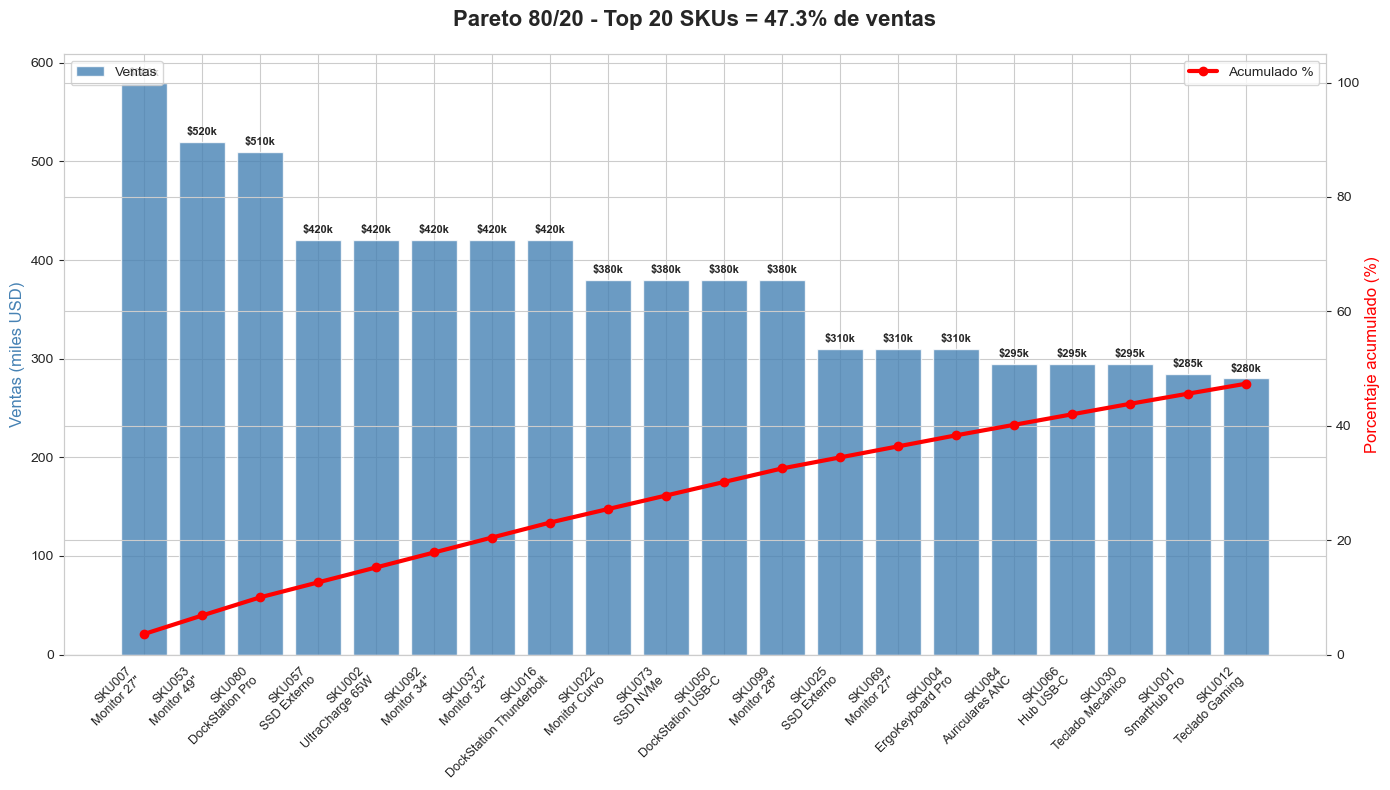

Mostrando Matriz Lifecycle vs Margen...


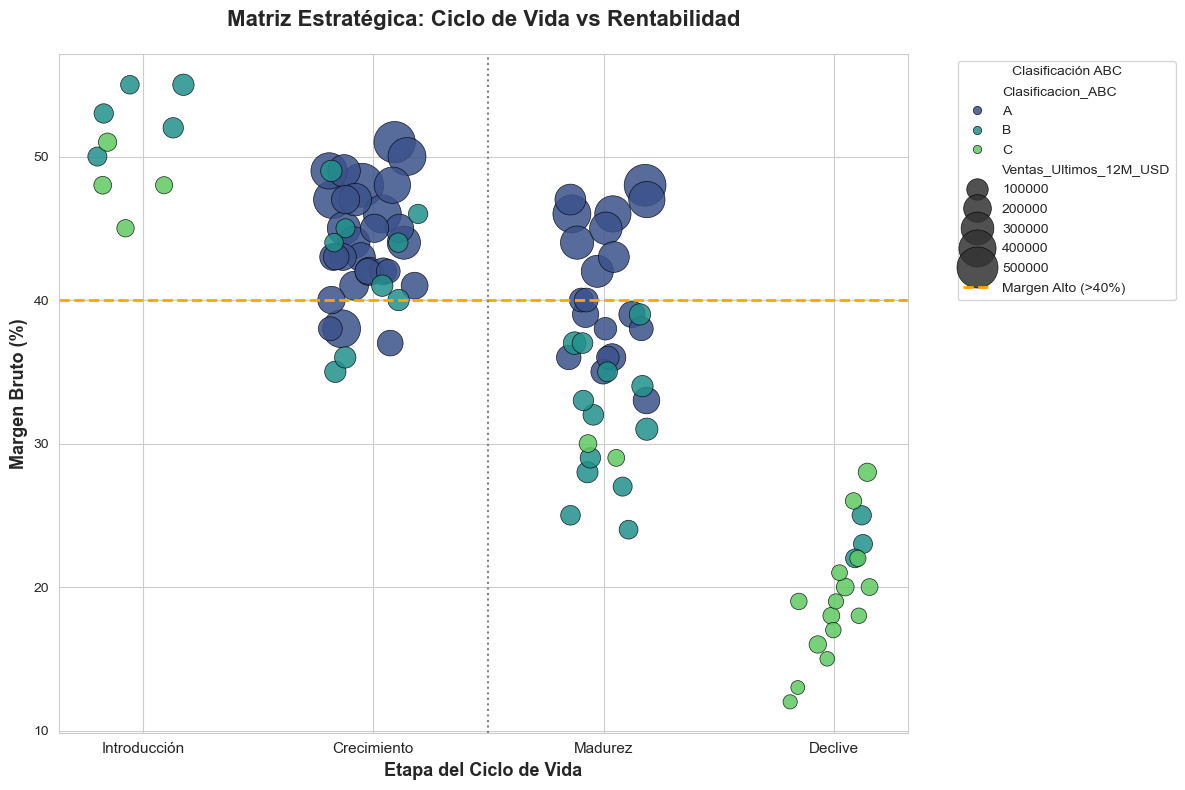

¡Gráficos mostrados correctamente!


In [17]:
# === 4. GRÁFICO 1: PARETO (Top 20) ===
print("Mostrando Pareto (Top 20 SKUs)...")
top_n = 20
df_top = df_pareto.head(top_n).copy()
df_top['Label'] = df_top['SKU'] + "\n" + df_top['Nombre_Producto'].str.split().str[:2].str.join(" ")

fig, ax1 = plt.subplots(figsize=(14, 8))
bars = ax1.bar(range(top_n), df_top['Ventas_Ultimos_12M_USD']/1000, color='steelblue', alpha=0.8)
ax1.set_ylabel('Ventas (miles USD)', fontsize=12, color='steelblue')
ax1.set_title(f'Pareto 80/20 - Top {top_n} SKUs = {df_top["Acumulado_%"].iloc[-1]:.1f}% de ventas',
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(range(top_n))
ax1.set_xticklabels(df_top['Label'], rotation=45, ha='right', fontsize=9)

# Línea acumulada
ax2 = ax1.twinx()
ax2.plot(range(top_n), df_top['Acumulado_%'], color='red', marker='o', linewidth=3, markersize=6)
ax2.set_ylabel('Porcentaje acumulado (%)', color='red', fontsize=12)
ax2.set_ylim(0, 105)

# Leyendas
ax1.legend(['Ventas'], loc='upper left')
ax2.legend(['Acumulado %'], loc='upper right')

# Anotar valores
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'${height:.0f}k', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# === 5. GRÁFICO 2: MATRIZ LIFECYCLE vs MARGEN (CORREGIDO) ===
print("Mostrando Matriz Lifecycle vs Margen...")

# === CREAR Etapa_Jitter ANTES DEL GRÁFICO ===
df_matriz = df_pareto.copy()
# Mapear etapas a números
etapa_map = {'Introducción': 0, 'Crecimiento': 1, 'Madurez': 2, 'Declive': 3}
df_matriz['Etapa_Num'] = df_matriz['Etapa_Ciclo_Vida'].map(etapa_map)

# Añadir jitter
np.random.seed(42)
df_matriz['Etapa_Jitter'] = df_matriz['Etapa_Num'] + np.random.uniform(-0.2, 0.2, size=len(df_matriz))

# === AHORA SÍ: GRÁFICO CON Etapa_Jitter ===
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df_matriz,
    x='Etapa_Jitter',           # ← EXISTE AHORA
    y='Margen_Bruto_Pct',
    hue='Clasificacion_ABC',
    size='Ventas_Ultimos_12M_USD',
    sizes=(100, 1000),
    palette='viridis',
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)

# Etiquetas personalizadas
etapas = ['Introducción', 'Crecimiento', 'Madurez', 'Declive']
plt.xticks(ticks=[0,1,2,3], labels=etapas, fontsize=11)
plt.xlabel('Etapa del Ciclo de Vida', fontsize=13, fontweight='bold')
plt.ylabel('Margen Bruto (%)', fontsize=13, fontweight='bold')
plt.title('Matriz Estratégica: Ciclo de Vida vs Rentabilidad', fontsize=16, fontweight='bold', pad=20)

# Líneas de referencia
plt.axhline(40, color='orange', linestyle='--', linewidth=2, label='Margen Alto (>40%)')
plt.axvline(1.5, color='gray', linestyle=':', linewidth=1.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Clasificación ABC')
plt.tight_layout()
plt.show()

print("¡Gráficos mostrados correctamente!")

In [ ]:
#EXPORTAR A EXCEL
print(f"Exportando a {output_file}...")

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Hoja 1: KPIs Resumen
    pd.DataFrame(list(kpis.items()), columns=['Indicador', 'Valor']).to_excel(writer, sheet_name='1_Resumen_KPIs', index=False)
    
    # Hoja 2: Pareto ABC
    df_pareto[['SKU', 'Nombre_Producto', 'Ventas_Ultimos_12M_USD', 'Acumulado_%', 'Clasificacion_ABC']].head(30).to_excel(writer, sheet_name='2_Pareto_ABC', index=False)
    
    # Hoja 3: Matriz Lifecycle
    df_matriz[['SKU', 'Nombre_Producto', 'Etapa_Ciclo_Vida', 'Margen_Bruto_Pct', 'Clasificacion_ABC']].to_excel(writer, sheet_name='3_Matriz_Lifecycle', index=False)
    
    # Hoja 4: Pipeline NPI
    df_npi[['SKU', 'Nombre_Producto', 'Proyectos_NPI', 'Fecha_Lanzamiento', 'Ventas_Pronosticadas_12M_USD']].to_excel(writer, sheet_name='4_Pipeline_NPI', index=False)
    
    # Hoja 5: Rationalization
    df_rationalization[['SKU', 'Nombre_Producto', 'Etapa_Ciclo_Vida', 'Variacion_YoY_Pct', 'Margen_Bruto_Pct', 'Estrategia_Recomendada']].to_excel(writer, sheet_name='5_Rationalization', index=False)
    
    # Hoja 6: Go/No-Go
    df_gonogo_summary = df_gonogo['GoNoGo_Decision'].value_counts().reset_index()
    df_gonogo_summary.columns = ['Decisión', 'Cantidad']
    df_gonogo_summary.to_excel(writer, sheet_name='6_GoNoGo_Resumen', index=False)
    
    df_gonogo[['SKU', 'Nombre_Producto', 'Etapa_Ciclo_Vida', 'GoNoGo_Decision', 'GoNoGo_Score', 'GoNoGo_Reasons']].to_excel(writer, sheet_name='6_GoNoGo_Detalle', index=False)

# Guardar gráficos
fig_pareto.savefig("grafico_pareto.png", dpi=150, bbox_inches='tight')
fig_matrix.figure.savefig("grafico_matriz.png", dpi=150, bbox_inches='tight')

print("¡Análisis completado!")
print(f"→ Excel generado: {output_file}")
print(f"→ Gráficos: grafico_pareto.png | grafico_matriz.png")
print("\n" + "="*60)
print("RECOMENDACIONES PARA LA REUNIÓN:")
print("="*60)
print(f"1. {kpis['SKUs en Declive (> -20%)']} SKUs en declive crítico → Revisar hoja '5_Rationalization'")
print(f"2. {df_gonogo['GoNoGo_Decision'].value_counts().get('NO-GO', 0)} SKUs con NO-GO → Proponer eliminación")
print(f"3. {len(df_npi)} NPIs en pipeline → Priorizar los 'Lanzado Q1/Q2'")
print(f"4. Top 10 SKUs = {df_pareto.head(10)['Ventas_Ultimos_12M_USD'].sum()/total_ventas_12m:.1%} de ventas → Proteger")
print(f"5. Margen promedio: {kpis['Margen Bruto Promedio (%)']} → Meta >40% en nuevos lanzamientos")